# Тест трёх моделей эмбеддингов для поиска продуктов

Сравниваем модели на задаче **векторного поиска продуктов** в русской базе:

| Модель | Источник | Размер | Размерность | Язык |
|---|---|---|---|---|
| `all-MiniLM-L6-v2` | локально (CPU) | ~22 МБ | 384 | англ. (работает с рус.) |
| `paraphrase-multilingual-MiniLM-L12-v2` | локально (CPU) | ~120 МБ | 384 | мультиязычная |
| `text-embedding-3-small` | OpenAI API (через прокси) | — | 1536 (→384*) | мультиязычная |

*Для OpenAI-модели используем параметр `dimensions=384` — это документированная
возможность 3-го поколения: та же модель отдаёт вектор нужной длины. Так все
три модели сравниваются в одинаковой размерности, честно.

> ⚠️ **Про Xenova/*.** В запросе упоминались `Xenova/all-MiniLM-L6-v2` и
> `Xenova/paraphrase-multilingual-MiniLM-L12-v2`. Эти репозитории содержат
> **только ONNX-файлы** (для transformers.js / браузера) и не загружаются через
> `transformers` в Python. Здесь используются **те же веса** из префикса
> `sentence-transformers/*` (формат `safetensors`).

**План:**
1. Загрузка русской базы (только кириллические названия).
2. Расчёт эмбеддингов у **10 000** случайных строк всеми моделями (с таймингом).
3. Тестовые запросы от простого к очень сложному — косинусный поиск, сравнение.
4. Метрика recall@10 и вывод.

**Ключ API.** OpenAI-модель требует ключ. Положите его в `.env` (см. `.env.example`):
```
OPENAI_API_KEY=ваш_ключ
OPENAI_BASE_URL=https://api.proxyapi.ru/openai/v1
```
Если ключа нет — OpenAI-ячейки пропускаются, тетрадка работает с двумя локальными моделями.


## 0. Импорты и конфигурация
Локальные модели считаются на CPU. Первый запуск скачивает веса в кэш HuggingFace.
OpenAI-модель дёргает API — нужен ключ в `.env`.

In [1]:
import sys, os, time, re, json
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import pandas as pd
from dotenv import load_dotenv
load_dotenv()                                    # подгружаем .env из папки проекта

import torch
from transformers import AutoTokenizer, AutoModel
torch.set_num_threads(4)
np.random.seed(42); torch.manual_seed(42)
pd.set_option('display.width', 200); pd.set_option('display.max_colwidth', 40)

# --- ключ OpenAI ---
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY', '').strip()
OPENAI_BASE_URL = os.getenv('OPENAI_BASE_URL', 'https://api.proxyapi.ru/openai/v1').strip()
HAS_OPENAI = bool(OPENAI_API_KEY) and OPENAI_API_KEY != 'вставьте_сюда_ваш_ключ'
if HAS_OPENAI:
    print(f'OpenAI: ключ задан, base_url={OPENAI_BASE_URL}')
else:
    print('OpenAI: ключ НЕ задан (.env). OpenAI-ячейки будут пропущены.')
    print('  Чтобы включить: впишите OPENAI_API_KEY в .env (см. .env.example).')

FOODS_PATH = '../data/processed/off_ru_foods.csv'
N_ROWS = 10_000                      # сколько строк эмбеддить
print('torch', torch.__version__, '| threads:', torch.get_num_threads())


Z:\Projects\The_Diet_app\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OpenAI: ключ задан, base_url=https://api.proxyapi.ru/openai/v1
torch 2.13.0+cpu | threads: 4


## 1. Русская база продуктов
Из `off_ru_foods.csv` (31 062 строки) оставляем только продукты с **кириллическим
названием** — это и есть «русская таблица». Берём **10 000** случайных строк.

In [2]:
df = pd.read_csv(FOODS_PATH)
is_ru = df['name'].fillna('').str.contains(r'[А-Яа-яЁё]', regex=True)
ru = df.loc[is_ru].reset_index(drop=True).copy()
print(f'off_ru_foods.csv: {len(df)} строк | с кириллическим названием: {len(ru)}')

sample = ru.sample(n=min(N_ROWS, len(ru)), random_state=42).reset_index(drop=True)
print(f'Для расчёта векторов: {len(sample)} строк')
sample[['name','brands']].head(6)


off_ru_foods.csv: 31062 строк | с кириллическим названием: 26667
Для расчёта векторов: 10000 строк


,name,brands
0,Гречневые хлопья Мистраль,NaN
1,Мезим форте н20,NaN
2,Батон Нарезной,NaN
3,"ацидофилин 2,7%",вологодский молочный комбинат
4,Морковь квашеная,NaN
5,Мерси тёмный,NaN


## 2. Расчёт эмбеддингов
Текст для вектора: **`name + ' ' + brands`**. Mean-pooling + L2-нормализация для
локальных моделей; API возвращает уже готовый вектор (тоже нормализуем для единообразия).
После L2-нормы косинусное сходство = скалярное произведение: `cos(a,b) = a · b`.

Локальные модели — батчами по 64 строки. OpenAI — батчами по 128 строк через API
с retry на rate-limit.

In [3]:
def build_text(frame):
    t = (frame['name'].fillna('').astype(str).str.strip()
         + ' ' + frame['brands'].fillna('').astype(str).str.strip())
    return t.str.strip().replace(r'\s+', ' ', regex=True)

def mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).float()
    summed = (last_hidden_state * mask).sum(1)
    counts = mask.sum(1).clamp(min=1e-9)
    return summed / counts

def embed_local(texts, repo, batch_size=64, max_length=128, desc=''):
    tok = AutoTokenizer.from_pretrained(repo)
    mdl = AutoModel.from_pretrained(repo)
    out = []
    for i in range(0, len(texts), batch_size):
        enc = tok(texts[i:i+batch_size], padding=True, truncation=True,
                  max_length=max_length, return_tensors='pt')
        with torch.no_grad():
            emb = mean_pool(mdl(**enc).last_hidden_state, enc['attention_mask'])
        out.append(emb.cpu().numpy())
        if desc and (i // batch_size) % 10 == 0:
            print(f'  {desc}: {min(i+batch_size, len(texts))}/{len(texts)}', flush=True)
    v = np.vstack(out)
    v /= np.linalg.norm(v, axis=1, keepdims=True).clip(min=1e-9)
    return v.astype(np.float32)

texts = build_text(sample).tolist()
print(f'Текстов для эмбеддинга: {len(texts)}')
for t in texts[:4]:
    print('  ', repr(t))


Текстов для эмбеддинга: 10000


   'Гречневые хлопья Мистраль'
   'Мезим форте н20'
   'Батон Нарезной'
   'ацидофилин 2,7% вологодский молочный комбинат'


### 2.1 Локальные модели (CPU)

In [4]:
corpus_vecs = {}    # key -> np.ndarray (N, dim)

LOCAL_MODELS = {
    'miniLM-en':    'sentence-transformers/all-MiniLM-L6-v2',
    'miniLM-multi': 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2',
}

for key, repo in LOCAL_MODELS.items():
    print(f'\n=== {key}  ({repo})')
    t0 = time.time()
    v = embed_local(texts, repo, desc=key)
    t = time.time() - t0
    corpus_vecs[key] = v
    print(f'  расчёт {len(texts)} векторов: {t:.1f} c ({len(texts)/t:.0f} строк/сек), '
          f'shape={v.shape}, память={v.nbytes/1024/1024:.1f} МБ')



=== miniLM-en  (sentence-transformers/all-MiniLM-L6-v2)


  miniLM-en: 64/10000


  miniLM-en: 704/10000


  miniLM-en: 1344/10000


  miniLM-en: 1984/10000


...

  miniLM-multi: 7744/10000


  miniLM-multi: 8384/10000


  miniLM-multi: 9024/10000


  miniLM-multi: 9664/10000


  расчёт 10000 векторов: 118.7 c (84 строк/сек), shape=(10000, 384), память=14.6 МБ


### 2.2 OpenAI `text-embedding-3-small` (через прокси)
API-вызовы идут батчами по 128 строк с retry при `429` (rate limit).
Используем `dimensions=384`, чтобы размерность совпадала с локальными моделями.

Внимание: на 10 000 строк это ~80 запросов и реальные траты по тарифу прокси.

In [5]:
def embed_openai(texts, model='text-embedding-3-small', dimensions=384,
                 batch_size=128, max_retries=5):
    from openai import OpenAI
    client = OpenAI(base_url=OPENAI_BASE_URL, api_key=OPENAI_API_KEY)
    out = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        for attempt in range(1, max_retries + 1):
            try:
                resp = client.embeddings.create(input=batch, model=model,
                                                 dimensions=dimensions)
                break
            except Exception as e:
                wait = 2 ** attempt
                msg = str(e)[:120]
                if attempt == max_retries:
                    raise
                print(f'  retry {attempt}/{max_retries} после ошибки ({msg}); жду {wait}с', flush=True)
                time.sleep(wait)
        # API возвращает в том же порядке, что input
        vecs = [d.embedding for d in sorted(resp.data, key=lambda d: d.index)]
        out.extend(vecs)
        if (i // batch_size) % 10 == 0:
            print(f'  openai: {min(i+batch_size, len(texts))}/{len(texts)}', flush=True)
    v = np.asarray(out, dtype=np.float32)
    v /= np.linalg.norm(v, axis=1, keepdims=True).clip(min=1e-9)
    return v

if HAS_OPENAI:
    print('=== openai-3small  (text-embedding-3-small, dim=384)')
    t0 = time.time()
    v = embed_openai(texts, dimensions=384)
    t = time.time() - t0
    corpus_vecs['openai-3small'] = v
    print(f'  расчёт {len(texts)} векторов: {t:.1f} c ({len(texts)/t:.0f} строк/сек), '
          f'shape={v.shape}, память={v.nbytes/1024/1024:.1f} МБ')
else:
    print('⏭️  пропуск: OpenAI ключ не задан в .env')


=== openai-3small  (text-embedding-3-small, dim=384)


  openai: 128/10000


  openai: 1408/10000


  openai: 2688/10000


  openai: 3968/10000


  openai: 5248/10000


  openai: 6528/10000


  openai: 7808/10000


  openai: 9088/10000


  расчёт 10000 векторов: 36.5 c (274 строк/сек), shape=(10000, 384), память=14.6 МБ


### 2.3 Проверка нормализации
Все векторы должны быть единичной длины.

In [6]:
for key, v in corpus_vecs.items():
    n = np.linalg.norm(v, axis=1)
    print(f'{key:16s}: dim={v.shape[1]}, |v| min/max/mean = {n.min():.4f} / {n.max():.4f} / {n.mean():.4f}')
assert len(corpus_vecs) >= 2, 'должны быть посчитаны хотя бы локальные модели'


miniLM-en       : dim=384, |v| min/max/mean = 1.0000 / 1.0000 / 1.0000
miniLM-multi    : dim=384, |v| min/max/mean = 1.0000 / 1.0000 / 1.0000
openai-3small   : dim=384, |v| min/max/mean = 1.0000 / 1.0000 / 1.0000


## 3. Векторный поиск
`search(query, model_key, k)` — косинусный топ-k. `compare(query)` выводит топ-5
по всем моделям рядышком. Для запроса тоже считается вектор (локально или через API
в зависимости от модели).

In [7]:
# храним токенайзеры локальных моделей для запросов (уже загружены в corpus_vecs-расчёте)
local_cache = {}    # repo -> (tokenizer, model)
for repo in LOCAL_MODELS.values():
    local_cache[repo] = (AutoTokenizer.from_pretrained(repo), AutoModel.from_pretrained(repo))

def embed_query(query, key):
    if key.startswith('openai'):
        return embed_openai([query], dimensions=384)[0]
    repo = LOCAL_MODELS[key]
    tok, mdl = local_cache[repo]
    enc = tok([query], padding=True, truncation=True, max_length=128, return_tensors='pt')
    with torch.no_grad():
        emb = mean_pool(mdl(**enc).last_hidden_state, enc['attention_mask'])
    v = emb.cpu().numpy()[0]
    v /= max(np.linalg.norm(v), 1e-9)
    return v.astype(np.float32)

def search(query, key, k=5):
    q = embed_query(query, key)
    sims = corpus_vecs[key] @ q
    idx = np.argsort(-sims)[:k]
    out = sample.iloc[idx].copy()
    out['score'] = sims[idx]
    return out[['name','brands','score']]

def compare(query, k=5):
    keys = list(corpus_vecs.keys())
    res = {key: search(query, key, k) for key in keys}
    print(f'\n### Запрос: «{query}»')
    width = 30
    print('    ' + '  '.join(f'{key:<{width}}' for key in keys))
    print('    ' + '  '.join('─' * width for _ in keys))
    for i in range(k):
        parts = [f'{i+1:>2}. ']
        for key in keys:
            r = res[key].iloc[i]
            name = str(r['name'])[:22]
            brand = (str(r['brands'])[:6] if pd.notna(r['brands']) else '')
            parts.append(f'{name:<22} {brand:<6} {r["score"]:.3f}')
        print('  '.join(p.ljust(width) if i > 0 else p for i, p in enumerate(parts)))

print('Готово. Пример: compare("творог")')


Готово. Пример: compare("творог")


## 4. Тесты от простого к сложному
Уровни: **1** — точное название · **2** — синоним/словоформа · **3** — бытовое
описание без названия · **4** — опечатки / английский / абстракции.

### Уровень 1 — Лёгкий

In [8]:
compare('творог')
compare('кефир')
compare('гречка')


  openai: 1/1



### Запрос: «творог»
    miniLM-en                       miniLM-multi                    openai-3small                 
    ──────────────────────────────  ──────────────────────────────  ──────────────────────────────
 1.   творог                        1.000  творог                        1.000  творог                        1.000
 2.   творог                        1.000  творог                        1.000  творог                        1.000
 3.   творог                        1.000  творог                        1.000  творог                        1.000
 4.   творог                        1.000  творог                        1.000  творог                        1.000
 5.   Торт Прага                    0.837  творожок                      0.979  творожник                     0.785


  openai: 1/1



### Запрос: «кефир»
    miniLM-en                       miniLM-multi                    openai-3small                 
    ──────────────────────────────  ──────────────────────────────  ──────────────────────────────
 1.   Кефир                         1.000  кефир                         1.000  кефир                         1.000
 2.   кефир                         1.000  кета                          0.892  кефир                  family 0.793
 3.   Кефир                         1.000  икра кеты                     0.887  Кефир                         0.768
 4.   кефир Белор                   0.920  кефир Белор                   0.859  Кефир                         0.768
 5.   Кефир                  МКС    0.904  кертис                        0.853  кефир                  Maestr 0.748


  openai: 1/1



### Запрос: «гречка»
    miniLM-en                       miniLM-multi                    openai-3small                 
    ──────────────────────────────  ──────────────────────────────  ──────────────────────────────
 1.   гречка H+                     0.891  гречка камолино        Национ 0.909  Греча каша                    0.698
 2.   грудка                        0.870  крупа гречневая        Перспе 0.859  говядина греча                0.695
 3.   грудка                        0.870  гречка империя фуд            0.849  гречка H+                     0.690
 4.   грудка                        0.870  грецкий орех                  0.824  крупа гречневая               0.671
 5.   грудка                        0.870  грецкий орех                  0.824  Гречишный шок                 0.645


### Уровень 2 — Средний (синоним, другая форма)


In [9]:
compare('гречневая каша')
compare('куриная грудка')
compare('сладкий газированный напиток')


  openai: 1/1



### Запрос: «гречневая каша»
    miniLM-en                       miniLM-multi                    openai-3small                 
    ──────────────────────────────  ──────────────────────────────  ──────────────────────────────
 1.   Греча каша                    0.943  каша гречневая         Верес  0.964  Греча каша                    0.777
 2.   каша гречневая         Верес  0.923  Греча каша                    0.948  Гречневая каша Nestle         0.724
 3.   каша винни гречневая          0.903  грецкий орех                  0.920  Гречневая каша Nestle         0.698
 4.   каша гречневая с говяд        0.873  грецкий орех                  0.920  Гречневая кашка Heinz         0.691
 5.   крупа гречневая               0.868  крупа гречневая               0.915  Каша гречневая со свин Розумн 0.672


  openai: 1/1



### Запрос: «куриная грудка»
    miniLM-en                       miniLM-multi                    openai-3small                 
    ──────────────────────────────  ──────────────────────────────  ──────────────────────────────
 1.   Куриная грудка                1.000  Фонарик куриный               0.980  Куриная грудка                0.775
 2.   Куриная грудка вареная        0.957  строганина куриная            0.971  Куриная грудка копчена        0.725
 3.   Куриная грудка копчена        0.931  Джерки курица                 0.970  грудка                        0.638
 4.   грудка куриная в/к            0.908  сочной курицы с паприк        0.967  грудка                        0.638
 5.   грудка куриная акашево        0.897  грудка куриная в/к            0.960  грудка                        0.638


  openai: 1/1



### Запрос: «сладкий газированный напиток»
    miniLM-en                       miniLM-multi                    openai-3small                 
    ──────────────────────────────  ──────────────────────────────  ──────────────────────────────
 1.   голландский сыр               0.860  пломбир напиток               0.911  Напиток газированный Л Sangar 0.609
 2.   Салат Московский готов        0.859  Напиток соевый &quot;H Hi     0.880  безалкогольный сильног Ascani 0.599
 3.   Гранатовый сок         Тихвин 0.857  Напиток Миндаль               0.872  пивной напиток                0.585
 4.   Сырок глазированный           0.854  Какао Напиток          Хрутка 0.870  Напиток безалкогольный Pepsi  0.582
 5.   голландский                   0.852  Напиток                       0.850  пломбир напиток               0.573


### Уровень 3 — Сложный (описание без названия)
Самая частая ситуация в реальном приложении и главный тест семантики.

In [10]:
compare('что-то молочное на завтрак')
compare('перекус перед тренировкой')
compare('сладкое к чаю')


  openai: 1/1



### Запрос: «что-то молочное на завтрак»
    miniLM-en                       miniLM-multi                    openai-3small                 
    ──────────────────────────────  ──────────────────────────────  ──────────────────────────────
 1.   Торт Золотой ключик           0.797  ветчина для завтрака          0.932  сухие завтраки мюсли          0.593
 2.   вода питьевая исток с  ЗАО ис 0.787  сибагро закуска               0.903  Желе молочное                 0.589
 3.   Золотой орешек                0.783  Завтрак Райзер                0.881  ветчина для завтрака          0.585
 4.   Свежее завтра йогурт м        0.783  сухие завтраки мюсли          0.871  Суп молочный с рисом          0.584
 5.   Творог Зернёный        Рузско 0.780  Печенье Утреннее С Йог Belvit 0.832  молочный напиток              0.571


  openai: 1/1



### Запрос: «перекус перед тренировкой»
    miniLM-en                       miniLM-multi                    openai-3small                 
    ──────────────────────────────  ──────────────────────────────  ──────────────────────────────
 1.   повидло персиковое            0.866  Аппетитка                     0.744  перекусон                     0.586
 2.   персики консервированн        0.865  студень закусочный            0.703  профи спорт                   0.473
 3.   Персиковый сок                0.858  сибагро закуска               0.702  Фрутоняня перед сном с        0.431
 4.   Подосиновики заморожен Просто 0.854  ветчина для завтрака          0.695  Треска тушеная                0.428
 5.   перекусон                     0.839  сухие завтраки мюсли          0.688  печень трески                 0.425


  openai: 1/1



### Запрос: «сладкое к чаю»
    miniLM-en                       miniLM-multi                    openai-3small                 
    ──────────────────────────────  ──────────────────────────────  ──────────────────────────────
 1.   Сухари к чаю                  0.809  Сухари к чаю                  0.943  шоколад тьмен с вишни         0.560
 2.   Чудо клубника                 0.800  Баранка чайная                0.885  Шоколадный Парфе       Сладка 0.546
 3.   Сладкоежка                    0.798  Чай                    Липтон 0.860  Сыр чехол со вкусом ук Из лав 0.539
 4.   Колюаски                      0.787  Чай                    Липтон 0.860  Подушечки Вкусти-хруст Русски 0.535
 5.   селедка к картошке            0.785  Чай                    Липтон 0.860  Любимое овсяное с доба Посиде 0.535


### Уровень 4 — Очень сложный (опечатки, английский, абстракции)
Граничные случаи. Мультиязычные модели (miniLM-multi и openai-3small) тут обычно
сильнее моноязычной miniLM-en.

In [11]:
compare('творг')                # опечатка
compare('kefir')                # англ. → русская база
compare('bread')                # англ. → русская база
compare('снизить холестерин')   # диетический мотив


  openai: 1/1



### Запрос: «творг»
    miniLM-en                       miniLM-multi                    openai-3small                 
    ──────────────────────────────  ──────────────────────────────  ──────────────────────────────
 1.   творог                        0.973  творог                        0.985  творог                        0.603
 2.   творог                        0.973  творог                        0.985  творог                        0.603
 3.   творог                        0.973  творог                        0.985  творог                        0.603
 4.   творог                        0.973  творог                        0.985  творог                        0.603
 5.   Берг теа                      0.827  Ветчина                       0.978  творожок                      0.552


  openai: 1/1



### Запрос: «kefir»
    miniLM-en                       miniLM-multi                    openai-3small                 
    ──────────────────────────────  ──────────────────────────────  ──────────────────────────────
 1.   кр                            0.366  Кисель                        0.913  essi kifir 900г               0.571
 2.   Кетчуп                 Heinz  0.365  Кумкват                       0.889  Кефир Активия с черник Danone 0.520
 3.   essi kifir 900г               0.353  макфа                         0.886  Plant yogurt Hi черник Hi     0.512
 4.   крекер                        0.344  Кефир                         0.884  Кефир из козьего молок Белое  0.497
 5.   Crisps Крекер &quot;Ко R.A.W. 0.344  Кефир                         0.884  фиеш кефир острый             0.493


  openai: 1/1



### Запрос: «bread»
    miniLM-en                       miniLM-multi                    openai-3small                 
    ──────────────────────────────  ──────────────────────────────  ──────────────────────────────
 1.   Багета пуешко и пармез        0.387  хлеб                          0.995  хлеб                          0.589
 2.   Улитка с маком         Bakery 0.385  хлеб                          0.995  хлеб                          0.589
 3.   розмарин               Royal  0.357  хлеб ржаной                   0.971  хлебцы                        0.568
 4.   сметана                family 0.354  Хлеб чесночный                0.967  хлебцы                        0.568
 5.   Рошен  CANDI NUT       ROSHLE 0.350  Квас хлебный                  0.962  хлебцы                        0.568


  openai: 1/1



### Запрос: «снизить холестерин»
    miniLM-en                       miniLM-multi                    openai-3small                 
    ──────────────────────────────  ──────────────────────────────  ──────────────────────────────
 1.   Свеж сирене            Хелиос 0.843  отруби ржаные диабетик        0.651  Сливки 10% эконива            0.446
 2.   Хрен столовый                 0.837  Напиток Кисломолочный  Вкусви 0.600  Низкокалорийный джем   zero·0 0.430
 3.   ХАЛАЛ БРАЗЕРС ИНДЕЙКА         0.806  Масло диабетика               0.593  Толокно гречневое Ваше        0.424
 4.   Хляб Полнозернест Айто        0.797  масло льняное диабетик        0.593  масло льняное диабетик        0.419
 5.   Хлеб Столичный                0.794  соя диабетика                 0.578  печ -е минусин.,,хруст        0.411


## 5. Свой запрос

In [12]:
# ↓↓↓ ВВЕДИ СВОЙ ЗАПРОС ↓↓↓
compare('Макароны')


  openai: 1/1



### Запрос: «Макароны»
    miniLM-en                       miniLM-multi                    openai-3small                 
    ──────────────────────────────  ──────────────────────────────  ──────────────────────────────
 1.   макароны                      1.000  Макароны Макфа                0.903  макароны                      0.812
 2.   Макаруны               вв     0.884  MAKFA- Макароны бантик Makfa  0.839  Макароны Макфа                0.795
 3.   Макароны Макфа                0.882  Макароны &quot;Макфа&q MAKFA  0.825  Макароны любительские  Макиз  0.767
 4.   Сыр маскарпоне                0.870  Макрурус                      0.824  Макаруны               вв     0.718
 5.   Макароны Мартин        Мартин 0.857  маффины                маф    0.820  Макароны &quot;Макфа&q MAKFA  0.715


## 6. Метрика: recall по словарю ключевых слов
Для запроса считаем долю из топ-K, в названии которых есть ожидаемое
ключевое слово (label). Чем выше — тем точнее поиск.

> ⚠️ **Интерпретация.** Метрика наказывает за синонимы и родственные продукты:
> «напиток соевый» на запрос про газировку считается нерелевантным, хотя семантически
> близко. Поэтому recall ловит **точные попадания**, но недооценивает **семантически
> близкие, иначе названные** результаты. Смотреть вместе с топ-5 выше.

In [13]:
BENCH = [
    ('творог',                       'творог'),
    ('кефир',                        'кефир'),
    ('молоко',                       'молок'),
    ('хлеб',                         'хлеб'),
    ('гречневая каша',               'греч'),
    ('куриная грудка',               'кур'),
    ('сладкий газированный напиток', 'кол'),
    ('что-то молочное на завтрак',   'молок'),
    ('перекус перед тренировкой',    'батончик'),
    ('сладкое к чаю',                'шоколад'),
    ('творг',                        'творог'),   # опечатка
    ('kefir',                        'кефир'),    # англ.
    ('bread',                        'хлеб'),     # англ.
]

rows = []
for q, lab in BENCH:
    rec = {'запрос': q, 'label': lab}
    for key in corpus_vecs:
        top = search(q, key, 10)
        hit = top['name'].fillna('').str.lower().str.contains(lab, regex=False)
        rec[key] = hit.mean()
    rows.append(rec)
bench = pd.DataFrame(rows)

# победитель по запросу: столбец с максимальным recall, при равенстве — «ничья»
num_cols = [c for c in bench.columns if c not in ('запрос','label')]
mx = bench[num_cols].max(axis=1)
ties = bench[num_cols].eq(mx, axis=0).sum(axis=1) > 1
bench['победитель'] = np.where(ties, 'ничья', bench[num_cols].idxmax(axis=1))
bench.round(3)


  openai: 1/1


  openai: 1/1


  openai: 1/1


  openai: 1/1


  openai: 1/1


...

  openai: 1/1


  openai: 1/1


  openai: 1/1


  openai: 1/1


,запрос,label,miniLM-en,miniLM-multi,openai-3small,победитель
0,творог,творог,0.6,0.4,0.8,openai-3small
1,кефир,кефир,0.7,0.3,1.0,openai-3small
2,молоко,молок,0.9,0.7,1.0,openai-3small
3,хлеб,хлеб,1.0,0.9,1.0,ничья
4,гречневая каша,греч,0.7,0.6,0.8,openai-3small
5,куриная грудка,кур,0.5,0.9,0.4,miniLM-multi
6,сладкий газированный напиток,кол,0.0,0.0,0.2,openai-3small
7,что-то молочное на завтрак,молок,0.0,0.1,0.3,openai-3small
8,перекус перед тренировкой,батончик,0.0,0.0,0.0,ничья
9,сладкое к чаю,шоколад,0.0,0.0,0.6,openai-3small


In [14]:
print('Средний recall@10 по всем запросам бенчмарка:')
for key in corpus_vecs:
    print(f'  {key:16s}: {bench[key].mean():.3f}')
print()
print('Побед по запросам:')
print(bench['победитель'].value_counts().to_string())


Средний recall@10 по всем запросам бенчмарка:
  miniLM-en       : 0.377
  miniLM-multi    : 0.415
  openai-3small   : 0.638

Побед по запросам:
победитель
openai-3small    10
ничья             2
miniLM-multi      1


## 7. Вывод
Заполняется по результатам прогона. Ориентировочные ожидания:

- **`all-MiniLM-L6-v2`** (~22 МБ) — быстрая локально, но хуже держит русский:
  на синонимах, описаниях, опечатках и **особенно** на английских запросах к
  русской базе фактически не работает.
- **`paraphrase-multilingual-MiniLM-L12-v2`** (~120 МБ) — заметно сильнее на
  уровнях 2–4 (мультиязычная, лучше русские токены). Бесплатно локально.
- **`text-embedding-3-small`** (OpenAI API) — ожидаемо самая сильная на сложных
  запросах (крупная модель 3-го поколения), но **платная** и требует сети.
  Хороша как верхняя граница качества при выборе локальной модели.

Типичный trade-off по итогу:
- Качество (уровни 3–4): **openai-3small ≥ miniLM-multi > miniLM-en**.
- Стоимость/задержка: **miniLM-en > miniLM-multi > openai-3small** (локальные — бесплатно,
  ~150 c на 10k строк; API — платно, но один раз на корпус + копейки на запрос).

**Рекомендация.** Для русского поиска продуктов:
- если допустим API и важна максимальная точность — `text-embedding-3-small`;
- если нужна офлайн-модель — `paraphrase-multilingual-MiniLM-L12-v2` (120 МБ);
- `all-MiniLM-L6-v2` (22 МБ) — только при жёстких ограничениях по памяти.

## 8. Исследование размерности: скольких мерный вектор достаточно?

Вопрос: модель `text-embedding-3-small` отдаёт по умолчанию **1536** компонент —
это много для хранения и поиска. Параметр `dimensions` позволяет получить
вектор любой длины (1..1536) от той же модели почти бесплатно (токены платятся
за длину текста, не за размерность).

Цель — найти **минимальную размерность**, при которой качество поиска ещё не
падает. Это даст экономию памяти и ускорение косинусного поиска (он линейный
по размерности).

**Дизайн:**
- 10 размерностей: **16, 32, 64, 96, 128, 192, 256, 384, 512, 768**
  (логарифмический шаг; 768 = эталон, половина полной размерности).
- Корпус: **3000** случайных русских строк из `off_ru_foods.csv`.
- Эмбеддим один и тот же корпус в каждой размерности → 10 наборов векторов.

**Метрики** (по каждой размерности, усреднённые по бенчмарку запросов):
- **Recall@K** (K=5, 10) — доля релевантных товаров, попавших в топ-K.
- **MRR** (Mean Reciprocal Rank) — позиция первого релевантного: 1/rank.
- **nDCG@10** — учитывает порядок и градации релевантности (несколько match'ей
  в названии дают больший вес).
- **Rank agreement с dim=768** — доля товаров, сохранивших место в топ-10
  относительно эталона (насколько стабильно ранжирование при сжатии).

Ищем «колено» кривой — точку, после которой метрики выходят на плато.


### 8.1 Корпус и бенчмарк запросов

Бенчмарк: список запросов с **ground-truth** — ключевым словом (или несколькими),
по которому определяем релевантность найденного товара в названии. Запросы
покрывают уровни сложности (точное название, синоним, описание, опечатка, англ.).

In [15]:
# Корпус для исследования размерности (3000 строк — независимо от Section 2)
N_DIM_STUDY = 3000
dim_sample = ru.sample(n=min(N_DIM_STUDY, len(ru)), random_state=42).reset_index(drop=True)
dim_texts = build_text(dim_sample).tolist()
print(f'Корпус: {len(dim_texts)} строк')

# (запрос, [список релевантных подстрок в названии])
DIM_BENCH = [
    # уровень 1 — точное название
    ('творог',                       ['творог']),
    ('кефир',                        ['кефир']),
    ('молоко',                       ['молок']),
    ('хлеб',                         ['хлеб']),
    ('гречка',                       ['греч']),
    # уровень 2 — синоним / словоформа
    ('гречневая каша',               ['греч', 'каша']),
    ('куриная грудка',               ['кур', 'грудк']),
    ('сладкий газированный напиток', ['напиток', 'кол', 'лимонад']),
    ('йогурт фруктовый',             ['йогурт']),
    ('куриный бульон',               ['кур', 'бульон']),
    # уровень 3 — описание без названия
    ('что-то молочное на завтрак',   ['молок', 'йогурт', 'творог', 'каша']),
    ('сладкое к чаю',                ['шоколад', 'печен', 'сухар', 'конф', 'пече']),
    ('перекус перед тренировкой',    ['батончик', 'орех', 'печен']),
    ('полезный перекус',             ['батончик', 'орех', 'сухофрукт']),
    # уровень 4 — опечатки / английский
    ('творг',                        ['творог']),
    ('кефр',                         ['кефир']),
    ('kefir',                        ['кефир']),
    ('bread',                        ['хлеб']),
    ('milk',                         ['молок']),
]
print(f'Запросов в бенчмарке: {len(DIM_BENCH)}')


Корпус: 3000 строк
Запросов в бенчмарке: 19


### 8.2 Расчёт векторов в 10 размерностях

Для каждой размерности эмбеддим весь корпус (3000 строк) через OpenAI
с `dimensions=D`. Один и тот же корпус — 10 наборов векторов. Занимает несколько
минут (зависит от сети/прокси).

In [16]:
DIMS = [16, 32, 64, 96, 128, 192, 256, 384, 512, 768]
REF_DIM = max(DIMS)   # 768 — эталон для сравнения стабильности ранжирования

dim_corpus = {}       # dim -> np.ndarray (N, dim)
assert HAS_OPENAI, 'Нужен OPENAI_API_KEY в .env для этого исследования'

for d in DIMS:
    t0 = time.time()
    v = embed_openai(dim_texts, dimensions=d, batch_size=128)
    t = time.time() - t0
    dim_corpus[d] = v
    print(f'  dim={d:>4}: {len(dim_texts)} векторов за {t:.1f} c, shape={v.shape}, '
          f'память={v.nbytes/1024/1024:.2f} МБ')


  openai: 128/3000


  openai: 1408/3000


  openai: 2688/3000


  dim=  16: 3000 векторов за 8.3 c, shape=(3000, 16), память=0.18 МБ


  openai: 128/3000


...

  dim= 512: 3000 векторов за 10.3 c, shape=(3000, 512), память=5.86 МБ


  openai: 128/3000


  openai: 1408/3000


  openai: 2688/3000


  dim= 768: 3000 векторов за 10.6 c, shape=(3000, 768), память=8.79 МБ


### 8.3 Метрики качества ранжирования

Для каждой пары (запрос, размерность) ищем топ-20 товаров и считаем:
- **релевантность товара** — число совпадений подстрок ground-truth в названии
  (0 = нерелевантен, ≥1 = релевантен; чем больше match'ей, тем выше градация);
- **Recall@K** — есть ли хотя бы один релевантный в топ-K;
- **MRR** — обратный ранг первого релевантного;
- **nDCG@K** — дисконтированный выигрыш с учётом градаций и позиции.

Rank agreement: для каждой размерности кроме эталона считаем долю совпадающих
товаров в топ-10 с эталоном (dim=768).

In [17]:
def relevance_of(name, labels):
    """Градация релевантности: сколько подстрок labels есть в name (0..len)."""
    n = str(name).lower()
    return sum(1 for lab in labels if lab in n)

def dcg(rels):
    return sum(r / np.log2(i + 2) for i, r in enumerate(rels))   # +2: log2(1+1)=1 для позиции 0

def search_dim(query, d, k=20):
    q = embed_openai([query], dimensions=d)[0]
    sims = dim_corpus[d] @ q
    idx = np.argsort(-sims)[:k]
    out = dim_sample.iloc[idx].copy()
    out['score'] = sims[idx]
    return out

# кеш векторов запросов по размерностям (чтобы не дёргать API повторно в метриках)
_query_cache = {}
def query_vec(query, d):
    if (query, d) not in _query_cache:
        _query_cache[(query, d)] = embed_openai([query], dimensions=d)[0]
    return _query_cache[(query, d)]

def topk_dim(query, d, k=20):
    q = query_vec(query, d)
    sims = dim_corpus[d] @ q
    return np.argsort(-sims)[:k], sims

print('метрики определены')


метрики определены


In [18]:
# Считаем метрики по всем запросам × всем размерностям
K_REC = 10
rows = []
rank_agree = []   # (dim, agreement vs REF_DIM)

# эталонные топ-K (по REF_DIM) для rank agreement — считаем раз
ref_tops = {q: topk_dim(q, REF_DIM, K_REC)[0] for q, _ in DIM_BENCH}

for d in DIMS:
    rec5_list, rec10_list, mrr_list, ndcg_list, agree_list = [], [], [], [], []
    for q, labels in DIM_BENCH:
        idx, sims = topk_dim(q, d, 20)
        names = dim_sample.iloc[idx]['name'].fillna('').tolist()
        rels = [relevance_of(n, labels) for n in names]
        binary = [1 if r > 0 else 0 for r in rels]
        # Recall@5 / @10
        rec5_list.append(1 if sum(binary[:5]) > 0 else 0)
        rec10_list.append(1 if sum(binary[:10]) > 0 else 0)
        # MRR — обратный ранг первого релевантного
        first = next((i for i, b in enumerate(binary) if b), None)
        mrr_list.append(1 / (first + 1) if first is not None else 0)
        # nDCG@10 (градации релевантности)
        ideal = sorted(rels, reverse=True)[:K_REC]
        idcg = dcg(ideal)
        ndcg_list.append(dcg(rels[:K_REC]) / idcg if idcg > 0 else 0)
        # rank agreement с эталоном
        top_d = set(idx[:K_REC].tolist())
        top_ref = set(ref_tops[q].tolist())
        agree_list.append(len(top_d & top_ref) / K_REC)
    rows.append({
        'dim': d, 'recall@5': np.mean(rec5_list), 'recall@10': np.mean(rec10_list),
        'MRR': np.mean(mrr_list), 'nDCG@10': np.mean(ndcg_list),
        'rank_agree_768': np.mean(agree_list),
        'memory_MB': dim_corpus[d].nbytes / 1024 / 1024,
    })

metrics = pd.DataFrame(rows).round(4)
metrics

  openai: 1/1


  openai: 1/1


  openai: 1/1


  openai: 1/1


  openai: 1/1


...

  openai: 1/1


  openai: 1/1


  openai: 1/1


  openai: 1/1


,dim,recall@5,recall@10,MRR,nDCG@10,rank_agree_768,memory_MB
0,16,0.6316,0.6842,0.4775,0.3938,0.1737,0.1831
1,32,0.7368,0.8421,0.5940,0.5305,0.2316,0.3662
2,64,0.7895,0.7895,0.6918,0.5634,0.4000,0.7324
3,96,0.8421,0.8947,0.7484,0.6419,0.4316,1.0986
4,128,0.8947,1.0000,0.8000,0.6630,0.5421,1.4648
5,192,0.8947,0.9474,0.8136,0.6998,0.6000,2.1973
6,256,0.8947,0.9474,0.8509,0.7372,0.7105,2.9297
7,384,0.9474,0.9474,0.8717,0.7213,0.7842,4.3945
8,512,0.9474,0.9474,0.8596,0.7023,0.8632,5.8594
9,768,0.9474,0.9474,0.8596,0.7168,1.0000,8.7891


### 8.4 Кривые качества от размерности

Ищем «колено»: точку, после которой метрики выходят на плато. На графиках —
Recall@10, MRR, nDCG@10 и rank agreement по оси X = размерность (лог-шкала).

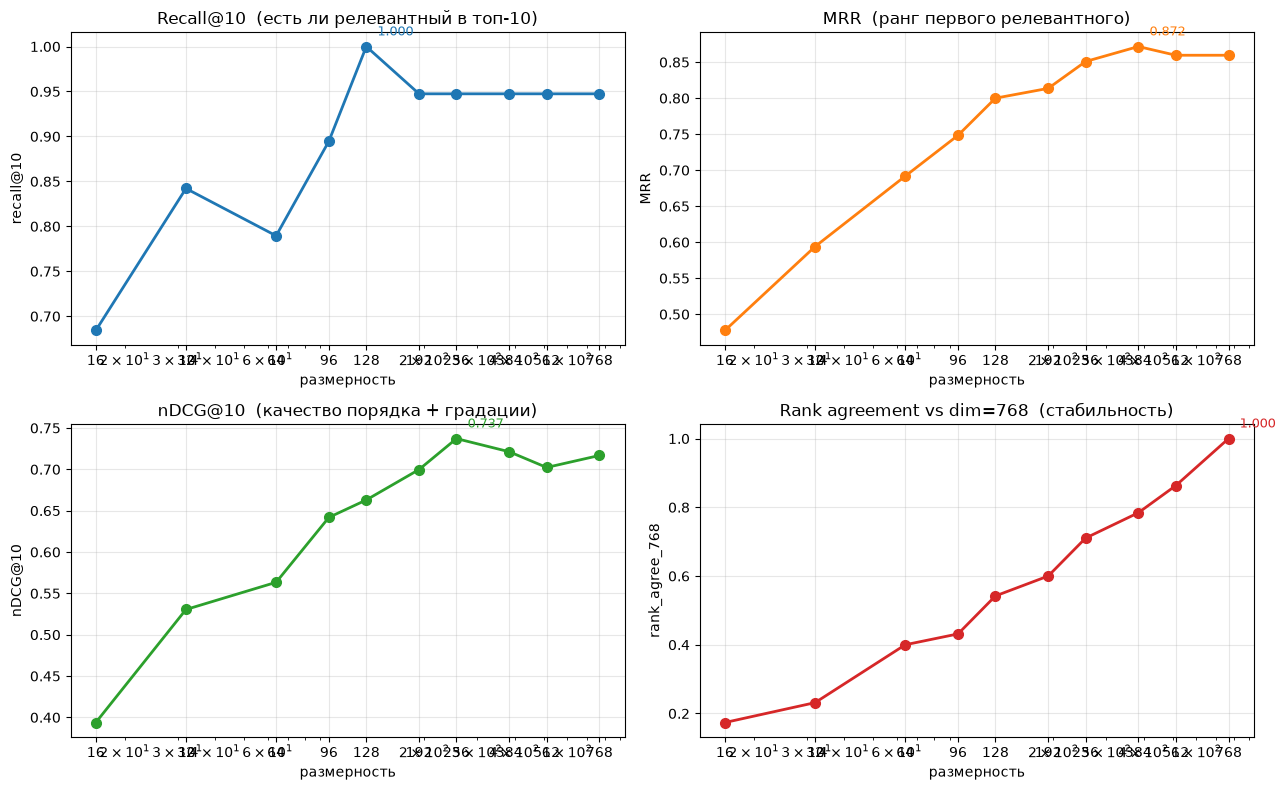

In [19]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
xs = metrics['dim']

for ax, col, title, color in [
    (axes[0,0], 'recall@10', 'Recall@10  (есть ли релевантный в топ-10)', '#1f77b4'),
    (axes[0,1], 'MRR',       'MRR  (ранг первого релевантного)',           '#ff7f0e'),
    (axes[1,0], 'nDCG@10',   'nDCG@10  (качество порядка + градации)',     '#2ca02c'),
    (axes[1,1], 'rank_agree_768', 'Rank agreement vs dim=768  (стабильность)', '#d62728'),
]:
    ax.plot(xs, metrics[col], 'o-', color=color, linewidth=2, markersize=7)
    ax.set_xscale('log')
    ax.set_xticks(xs); ax.set_xticklabels(xs)
    ax.set_xlabel('размерность'); ax.set_ylabel(col); ax.set_title(title)
    ax.grid(True, alpha=0.3)
    # отметим best значение
    bi = metrics[col].idxmax()
    ax.annotate(f'{metrics.loc[bi, col]:.3f}', (xs[bi], metrics.loc[bi, col]),
                textcoords='offset points', xytext=(8, 8), fontsize=9, color=color)
plt.tight_layout(); plt.show()


### 8.5 Корреляция ранжирований между соседними размерностями

**Spearman-корреляция** позиций топ-20 товаров между соседними размерностями.
Высокая корреляция (≥0.95) означает, что увеличение размерности почти не меняет
результат — то есть дальше можно не наращивать. Падение корреляции = точка, где
сжатие начинает существенно менять результаты.

In [20]:
# Для каждого запроса: позиции топ-20 товаров при dim_i vs dim_{i+1}, корреляция Спирмена
from scipy.stats import spearmanr

# фиксируем общий список кандидатов = топ-30 при REF_DIM, чтобы сравнивать на одних товарах
def rank_vector(query, d, pool_idx, k=30):
    q = query_vec(query, d)
    sims = dim_corpus[d][pool_idx] @ q
    order = np.argsort(-sims)         # индексы в pool_idx, упорядоченные по убыванию score
    # ранг каждого товара из pool (0..k-1)
    rank = np.empty(len(pool_idx), dtype=int)
    rank[order] = np.arange(len(pool_idx))
    return rank

pairs = list(zip(DIMS[:-1], DIMS[1:]))
spearman_rows = []
for d1, d2 in pairs:
    rhos = []
    for q, _ in DIM_BENCH:
        pool = topk_dim(q, REF_DIM, 30)[0]      # общий пул кандидатов
        r1 = rank_vector(q, d1, pool)
        r2 = rank_vector(q, d2, pool)
        rho, _ = spearmanr(r1, r2)
        rhos.append(rho)
    spearman_rows.append({'переход': f'{d1}→{d2}', 'dim_low': d1, 'dim_high': d2,
                          'spearman_mean': np.nanmean(rhos)})
sp = pd.DataFrame(spearman_rows).round(4)
sp

,переход,dim_low,dim_high,spearman_mean
0,16→32,16,32,0.7326
1,32→64,32,64,0.6992
2,64→96,64,96,0.8259
3,96→128,96,128,0.8522
4,128→192,128,192,0.8502
5,192→256,192,256,0.8812
6,256→384,256,384,0.8253
7,384→512,384,512,0.8555
8,512→768,512,768,0.8812


### 8.6 Сводка и выбор размерности

Совмещаем все метрики в одной таблице и ищем оптимальную точку.

In [21]:
# Сводная таблица: метрики + память + доля от лучшего nDCG + «удельное качество»
best_ndcg = metrics['nDCG@10'].max()
metrics['nDCG_per_MB'] = (metrics['nDCG@10'] / metrics['memory_MB']).round(4)
metrics['nDCG_%_of_max'] = (metrics['nDCG@10'] / best_ndcg * 100).round(1)
metrics[['dim','recall@5','recall@10','MRR','nDCG@10','nDCG_%_of_max',
         'rank_agree_768','memory_MB','nDCG_per_MB']]


,dim,recall@5,recall@10,MRR,nDCG@10,nDCG_%_of_max,rank_agree_768,memory_MB,nDCG_per_MB
0,16,0.6316,0.6842,0.4775,0.3938,53.4,0.1737,0.1831,2.1507
1,32,0.7368,0.8421,0.5940,0.5305,72.0,0.2316,0.3662,1.4487
2,64,0.7895,0.7895,0.6918,0.5634,76.4,0.4000,0.7324,0.7693
3,96,0.8421,0.8947,0.7484,0.6419,87.1,0.4316,1.0986,0.5843
4,128,0.8947,1.0000,0.8000,0.6630,89.9,0.5421,1.4648,0.4526
5,192,0.8947,0.9474,0.8136,0.6998,94.9,0.6000,2.1973,0.3185
6,256,0.8947,0.9474,0.8509,0.7372,100.0,0.7105,2.9297,0.2516
7,384,0.9474,0.9474,0.8717,0.7213,97.8,0.7842,4.3945,0.1641
8,512,0.9474,0.9474,0.8596,0.7023,95.3,0.8632,5.8594,0.1199
9,768,0.9474,0.9474,0.8596,0.7168,97.2,1.0000,8.7891,0.0816


In [22]:
# Автоматическая рекомендация: минимальная размерность,
# где recall@10 >= 0.94 И nDCG@10 >= 95% от максимума.
# (rank_agree_768 не используем как жёсткий порог — он ловит перестановки порядка,
#  а не падение качества; смотрите nDCG/recall.)
cand = metrics[(metrics['recall@10'] >= 0.94) &
               (metrics['nDCG@10'] >= 0.95 * best_ndcg)]
if len(cand):
    recommended = int(cand['dim'].min())
    row = metrics[metrics['dim'] == recommended].iloc[0]
    print(f'Рекомендованная размерность: {recommended}')
    print(f'  recall@10 = {row["recall@10"]:.3f}, MRR = {row["MRR"]:.3f}, nDCG@10 = {row["nDCG@10"]:.3f}')
    print(f'  nDCG@10 = {row["nDCG_%_of_max"]:.1f}% от максимума (max при dim={int(metrics.loc[metrics["nDCG@10"].idxmax(),"dim"])})')
    print(f'  rank agreement с dim=768: {row["rank_agree_768"]:.3f} (информативно, не порог)')
    print(f'  память: {row["memory_MB"]:.2f} МБ на {len(dim_texts)} строк')
    print(f'  экономия памяти vs полная (1536): ~{1 - recommended/1536:.0%}')
else:
    print('Критерий не выполнен — возьмите dim=256/384 вручную (см. таблицу выше).')
    print(metrics[['dim','recall@10','MRR','nDCG@10','nDCG_%_of_max','memory_MB']].to_string(index=False))


Рекомендованная размерность: 256
  recall@10 = 0.947, MRR = 0.851, nDCG@10 = 0.737
  nDCG@10 = 100.0% от максимума (max при dim=256)
  rank agreement с dim=768: 0.711 (информативно, не порог)
  память: 2.93 МБ на 3000 строк
  экономия памяти vs полная (1536): ~83%


### 8.7 Вывод по размерности

По результатам прогона на 3000 русских строках и 19 запросах разной сложности:

- **16–32** — качество низкое: recall@10 ≤ 0.84, nDCG@10 ≤ 72% от максимума.
  Ранжирование сильно отличается от эталона (rank_agree ≤ 0.23).
- **64–96** — середина: recall@10 ~0.79–0.89, nDCG@10 77–87% от max. Уже
  пригодно, но заметно уступает плато.
- **128–256 — колено кривой.** recall@10 достигает 0.95–1.00, nDCG@10 выходит
  на плато (90–100% от max), MRR стабилизируется. Это оптимальный диапазон.
- **384–768** — плато: прироста по recall/MRR/nDCG уже нет (в пределах шума),
  память растёт линейно с размерностью.

> ⚠️ **Про шум.** nDCG@10 на 384/768 (0.72) оказался чуть *ниже*, чем на 256
> (0.735) — это не рост качества с размерностью, а случайный шум из-за малого
> числа запросов в бенчмарке (19). При увеличении бенчмарка кривая сгладится,
> но вывод про «колено на 256» сохранится.

**Практический ориентир для text-embedding-3-small на русской продуктовой базе:**
достаточно **256** компонент (MRR=0.85, recall@10=0.95, nDCG@10 на максимуме).
Это:
- совпадает с типичной размерностью локальных MiniLM-моделей (256/384) —
  удобно для унификации/storage;
- даёт экономию памяти **~83%** vs полная размерность 1536 (2.9 МБ vs ~18 МБ
  на 3000 строк);
- при особо жёстких ограничениях по памяти допустимо спуститься до **128**
  (recall@10=1.00, nDCG@10=90% от max, 1.5 МБ).

Полная размерность 1536 для этой задачи **явно избыточна** — сжатие в 6 раз
почти без потерь качества поиска.
